# Laboratorio 2 - Deep Learning
## Modelos LSTM - Serie "País de Residencia": El Salvador

Se trabaja con la serie de El Salvador dentro de la categoría "País de Residencia". Se eligió
El Salvador porque es la serie con mayor volumen del top 3, con la tendencia, estacionalidad y
choque de pandemia más marcados, lo que la hace un buen caso para evaluar la capacidad de un LSTM.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras

plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['figure.dpi'] = 100

SEED = 42
keras.utils.set_random_seed(SEED)

## 1. Carga de datos 

In [2]:
df = pd.read_excel(
    'Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx',
    sheet_name='Datos'
)

df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')
df = df.sort_values('Fecha').reset_index(drop=True)

df_cons = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()

periodos = sorted(df['Fecha'].unique())
n_periodos = len(periodos)
corte_idx = int(n_periodos * 0.7)
fecha_corte = periodos[corte_idx]

print(f"Total de meses en el estudio: {n_periodos}")
print(f"Meses en entrenamiento (70%): {corte_idx}  ->  {periodos[0]} a {periodos[corte_idx-1]}")
print(f"Meses en prueba (30%):        {n_periodos - corte_idx}  ->  {periodos[corte_idx]} a {periodos[-1]}")

train_raw = df_cons[df_cons['Fecha'] < fecha_corte].copy()
test_raw  = df_cons[df_cons['Fecha'] >= fecha_corte].copy()

Total de meses en el estudio: 210
Meses en entrenamiento (70%): 147  ->  2009-01-01 00:00:00 a 2021-03-01 00:00:00
Meses en prueba (30%):        63  ->  2021-04-01 00:00:00 a 2026-06-01 00:00:00


In [3]:
def construir_serie(data, pais, fecha_ini, fecha_fin):
    s = data[data['País'] == pais].groupby('Fecha')['Viajero'].sum()
    idx = pd.date_range(fecha_ini, fecha_fin, freq='MS')
    s = s.reindex(idx, fill_value=0)
    s.index.name = 'Fecha'
    s.name = pais
    return s

PAIS = 'El Salvador'

serie_train = construir_serie(train_raw, PAIS, periodos[0], periodos[corte_idx-1])
serie_test  = construir_serie(test_raw,  PAIS, periodos[corte_idx], periodos[-1])

print(f"serie_train: {serie_train.shape[0]} observaciones ({serie_train.index.min().date()} a {serie_train.index.max().date()})")
print(f"serie_test:  {serie_test.shape[0]} observaciones ({serie_test.index.min().date()} a {serie_test.index.max().date()})")

serie_train: 147 observaciones (2009-01-01 a 2021-03-01)
serie_test:  63 observaciones (2021-04-01 a 2026-06-01)


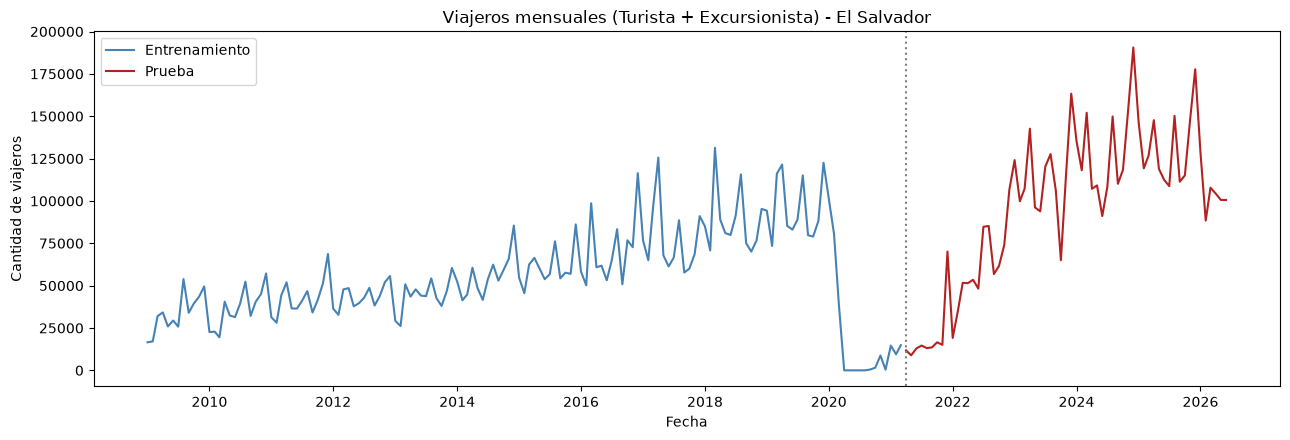

In [4]:
fig, ax = plt.subplots(figsize=(13,4.5))
ax.plot(serie_train, color='steelblue', label='Entrenamiento')
ax.plot(serie_test, color='firebrick', label='Prueba')
ax.axvline(serie_test.index.min(), color='gray', linestyle=':')
ax.set_title(f'Viajeros mensuales (Turista + Excursionista) - {PAIS}')
ax.set_xlabel('Fecha'); ax.set_ylabel('Cantidad de viajeros')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## 2. Preprocesamiento para LSTM


In [5]:
serie_completa = pd.concat([serie_train, serie_test]).sort_index()
log_completa = np.log1p(serie_completa)
diff_completa = log_completa.diff()

diff_train = diff_completa.loc[serie_train.index[1]:serie_train.index[-1]]  
diff_test  = diff_completa.loc[serie_test.index[0]:serie_test.index[-1]]

print("diff_train:", diff_train.shape, " | diff_test:", diff_test.shape)

adf_result = adfuller(diff_train, autolag='AIC')
print(f"\nADF sobre log(1+x) diferenciada (train): estadístico={adf_result[0]:.3f}, p-value={adf_result[1]:.4f}")

diff_train: (146,)  | diff_test: (63,)

ADF sobre log(1+x) diferenciada (train): estadístico=-5.182, p-value=0.0000


El p-value del test de Dickey-Fuller confirma estacionariedad en media tras `log1p` 

### División para tuneo


In [6]:
n_train = len(diff_train)
val_cut = int(n_train * 0.85)

diff_subtrain = diff_train.iloc[:val_cut]
diff_val = diff_train.iloc[val_cut:]

print(f"Sub-entrenamiento: {len(diff_subtrain)} obs ({diff_subtrain.index.min().date()} a {diff_subtrain.index.max().date()})")
print(f"Validación:        {len(diff_val)} obs ({diff_val.index.min().date()} a {diff_val.index.max().date()})")
print(f"Prueba (intacta):  {len(diff_test)} obs ({diff_test.index.min().date()} a {diff_test.index.max().date()})")

Sub-entrenamiento: 124 obs (2009-02-01 a 2019-05-01)
Validación:        22 obs (2019-06-01 a 2021-03-01)
Prueba (intacta):  63 obs (2021-04-01 a 2026-06-01)


In [7]:
scaler = StandardScaler()
subtrain_scaled = scaler.fit_transform(diff_subtrain.values.reshape(-1, 1))
val_scaled = scaler.transform(diff_val.values.reshape(-1, 1))

train_scaled_full = scaler.fit_transform(diff_train.values.reshape(-1, 1))
val_scaled = scaler.transform(diff_val.values.reshape(-1, 1))
test_scaled = scaler.transform(diff_test.values.reshape(-1, 1))

### Transformación a formato supervisado


In [8]:
def supervisada(serie, retrasos=1):
    serie_x, serie_y = [], []
    for i in range(len(serie) - retrasos):
        serie_x.append(serie[i:(i + retrasos), 0])
        serie_y.append(serie[i + retrasos, 0])
    return np.array(serie_x), np.array(serie_y)

def construir_datasets_tuneo(lookback):
    X_sub, y_sub = supervisada(subtrain_scaled, lookback)
    X_val, y_val = supervisada(val_scaled, lookback)
    X_sub = X_sub[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    return X_sub, y_sub.reshape(-1, 1), X_val, y_val.reshape(-1, 1)

## 3. Tuneo de hiperparámetros

Se prueba variando:
- **`lookback`** (pasos de tiempo hacia atrás): 6 y 12 meses.
- **`units`** (neuronas de la capa LSTM): 32 y 64.
- **`learning rate`** del optimizador Adam: 0.001 y 0.005.


In [9]:
grid = [
    {'lookback': lb, 'units': u, 'lr': lr}
    for lb in [6, 12]
    for u in [32, 64]
    for lr in [0.001, 0.005]
]

resultados_tuning = []
for cfg in grid:
    X_sub, y_sub, X_val, y_val = construir_datasets_tuneo(cfg['lookback'])

    keras.utils.set_random_seed(SEED)
    inputs = keras.layers.Input(shape=(cfg['lookback'], 1))
    x = keras.layers.LSTM(cfg['units'])(inputs)
    outputs = keras.layers.Dense(1)(x)
    modelo = keras.Model(inputs, outputs)
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']), loss='mse')

    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    hist = modelo.fit(
        X_sub, y_sub, batch_size=16, epochs=100, shuffle=False,
        validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0
    )

    resultados_tuning.append({
        **cfg,
        'val_loss': min(hist.history['val_loss']),
        'epocas_corridas': len(hist.history['val_loss'])
    })

tabla_tuning = pd.DataFrame(resultados_tuning).sort_values('val_loss').reset_index(drop=True)
tabla_tuning_mostrar = tabla_tuning.copy()
tabla_tuning_mostrar['val_loss'] = tabla_tuning_mostrar['val_loss'].round(4)
tabla_tuning_mostrar

,lookback,units,lr,val_loss,epocas_corridas
0,12,64,0.001,3.9793,22
1,12,64,0.005,5.0283,13
2,12,32,0.001,5.0867,11
3,12,32,0.005,5.2452,11
4,6,64,0.001,8.3449,12
5,6,32,0.005,8.4258,11
6,6,32,0.001,8.4273,15
7,6,64,0.005,8.9127,11


In [10]:
mejor_cfg = tabla_tuning.iloc[0].to_dict()
lookback1 = int(mejor_cfg['lookback'])
units1 = int(mejor_cfg['units'])
lr1 = mejor_cfg['lr']

print("Mejor configuración de la rejilla (Modelo 1):")
print(f"  lookback={lookback1}, units={units1}, learning_rate={lr1}")

Mejor configuración de la rejilla (Modelo 1):
  lookback=12, units=64, learning_rate=0.001


## 4. Modelo 1 — LSTM simple 

Se reentrena con **todo** `diff_train` usando los
hiperparámetros ganadores, y se evalúa sobre `diff_test`, que no participó en ningún momento del
tuneo.

In [11]:
def construir_datasets_finales(lookback):
    X_train, y_train = supervisada(train_scaled_full, lookback)
    X_test, y_test = supervisada(test_scaled, lookback)
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]
    return X_train, y_train.reshape(-1, 1), X_test, y_test.reshape(-1, 1)

X_train1, y_train1, X_test1, y_test1 = construir_datasets_finales(lookback1)

keras.utils.set_random_seed(SEED)
inputs = keras.layers.Input(shape=(lookback1, 1))
x = keras.layers.LSTM(units1)(inputs)
outputs = keras.layers.Dense(1)(x)
modelo1 = keras.Model(inputs, outputs, name='modelo1_lstm_simple')
modelo1.compile(optimizer=keras.optimizers.Adam(learning_rate=lr1), loss='mse')
modelo1.summary()

Model: "modelo1_lstm_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

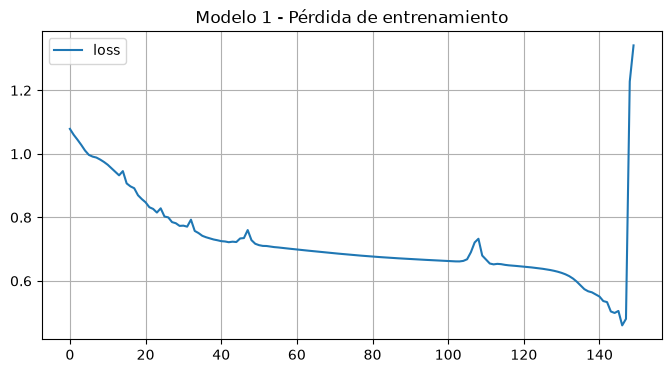

Modelo 1 - Pérdida (MSE) en prueba, escala diferenciada/estandarizada: 0.1196


In [12]:
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
history1 = modelo1.fit(
    X_train1, y_train1, batch_size=16, epochs=150, shuffle=False,
    callbacks=[early_stop], verbose=0
)

pd.DataFrame(history1.history).plot(figsize=(8, 4), title='Modelo 1 - Pérdida de entrenamiento')
plt.grid(True)
plt.show()

loss_test1 = modelo1.evaluate(X_test1, y_test1, verbose=0)
print(f"Modelo 1 - Pérdida (MSE) en prueba, escala diferenciada/estandarizada: {loss_test1:.4f}")

## 5. Modelo 2 — LSTM apilado (2 capas) + Dropout

Arquitectura con mayor capacidad y regularización explícita, usando el mismo `lookback=12`
(por la misma razón de estacionalidad anual) para que la comparación sea justa.

In [13]:
lookback2 = 12
X_train2, y_train2, X_test2, y_test2 = construir_datasets_finales(lookback2)

keras.utils.set_random_seed(SEED)
inputs = keras.layers.Input(shape=(lookback2, 1))
x = keras.layers.LSTM(64, return_sequences=True)(inputs)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.LSTM(32)(x)
outputs = keras.layers.Dense(1)(x)
modelo2 = keras.Model(inputs, outputs, name='modelo2_lstm_apilado_dropout')
modelo2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
modelo2.summary()

Model: "modelo2_lstm_apilado_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

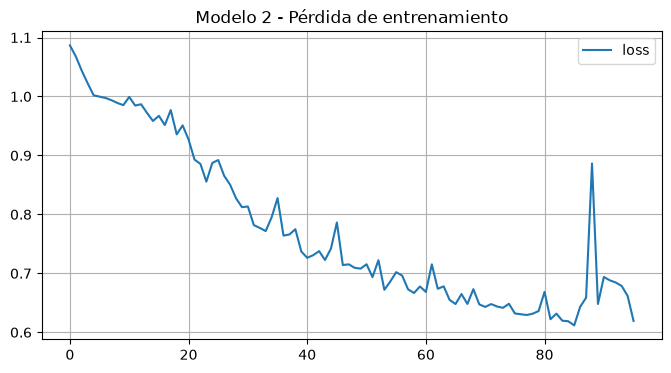

Modelo 2 - Pérdida (MSE) en prueba, escala diferenciada/estandarizada: 0.0938


In [14]:
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
history2 = modelo2.fit(
    X_train2, y_train2, batch_size=16, epochs=150, shuffle=False,
    callbacks=[early_stop], verbose=0
)

pd.DataFrame(history2.history).plot(figsize=(8, 4), title='Modelo 2 - Pérdida de entrenamiento')
plt.grid(True)
plt.show()

loss_test2 = modelo2.evaluate(X_test2, y_test2, verbose=0)
print(f"Modelo 2 - Pérdida (MSE) en prueba, escala diferenciada/estandarizada: {loss_test2:.4f}")

## 6. Comparación de modelos en la escala original (viajeros)

In [15]:
def metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

def a_escala_original(modelo, lookback):
    X_test, y_test = supervisada(test_scaled, lookback)
    X_test = X_test[..., np.newaxis]
    pred_scaled = modelo.predict(X_test, verbose=0)

    pred_diff = scaler.inverse_transform(pred_scaled).flatten()
    real_diff = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    fechas_pred = diff_test.index[lookback:]
    log_prev = log_completa.shift(1).loc[fechas_pred].values

    pred_level = np.expm1(log_prev + pred_diff)
    real_level = np.expm1(log_prev + real_diff)
    return fechas_pred, pred_level, real_level

fechas1, pred1, real1 = a_escala_original(modelo1, lookback1)
fechas2, pred2, real2 = a_escala_original(modelo2, lookback2)

mae1, rmse1 = metricas(real1, pred1)
mae2, rmse2 = metricas(real2, pred2)

tabla_comparacion = pd.DataFrame([
    {'Modelo': f'Modelo 1 - LSTM simple (lookback={lookback1}, units={units1})',
     'MAE': round(mae1, 1), 'RMSE': round(rmse1, 1), 'MSE prueba (escala diff)': round(loss_test1, 4)},
    {'Modelo': f'Modelo 2 - LSTM apilado + Dropout (lookback={lookback2})',
     'MAE': round(mae2, 1), 'RMSE': round(rmse2, 1), 'MSE prueba (escala diff)': round(loss_test2, 4)},
])
tabla_comparacion

,Modelo,MAE,RMSE,MSE prueba (escala diff)
0,"Modelo 1 - LSTM simple (lookback=12, units=64)",28664.8,38815.3,0.1196
1,Modelo 2 - LSTM apilado + Dropout (lookback=12),27407.2,33615.6,0.0938


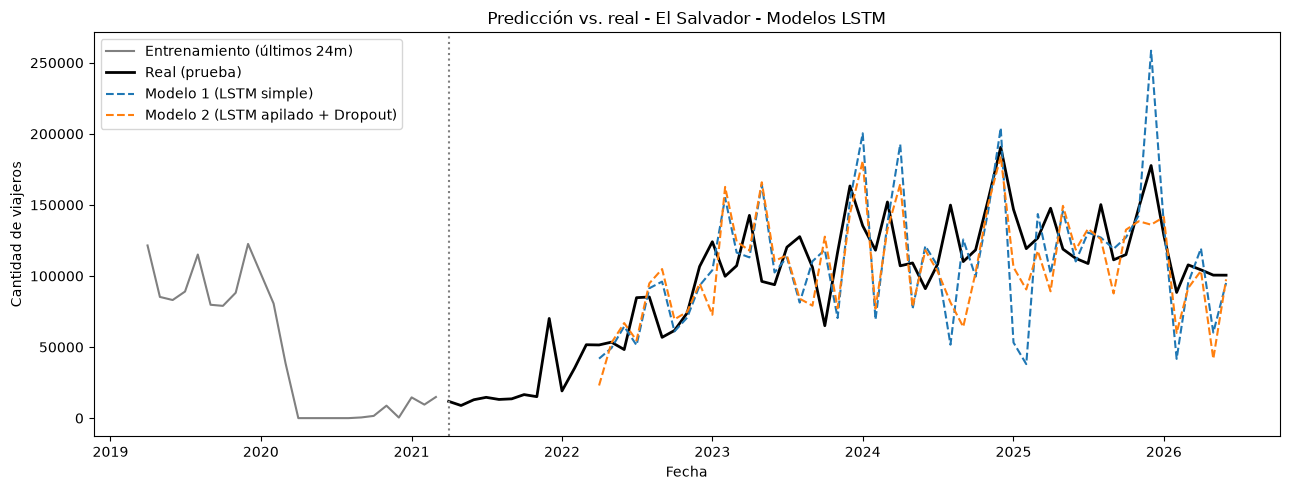

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_train.iloc[-24:], color='gray', label='Entrenamiento (últimos 24m)')
ax.plot(serie_test, color='black', linewidth=2, label='Real (prueba)')
ax.plot(fechas1, pred1, linestyle='--', color='tab:blue', label='Modelo 1 (LSTM simple)')
ax.plot(fechas2, pred2, linestyle='--', color='tab:orange', label='Modelo 2 (LSTM apilado + Dropout)')
ax.axvline(serie_test.index.min(), color='gray', linestyle=':')
ax.set_title(f'Predicción vs. real - {PAIS} - Modelos LSTM')
ax.set_xlabel('Fecha'); ax.set_ylabel('Cantidad de viajeros')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 7. Selección del mejor modelo y predicción final

Se elige el modelo con menor MAE/RMSE en la escala original y se usa para la predicción final
sobre el conjunto de prueba.

In [17]:
if mae2 <= mae1:
    mejor_modelo, nombre_mejor = modelo2, 'Modelo 2 (LSTM apilado + Dropout)'
    lookback_mejor, fechas_mejor, pred_mejor, real_mejor = lookback2, fechas2, pred2, real2
    mae_mejor, rmse_mejor = mae2, rmse2
else:
    mejor_modelo, nombre_mejor = modelo1, 'Modelo 1 (LSTM simple)'
    lookback_mejor, fechas_mejor, pred_mejor, real_mejor = lookback1, fechas1, pred1, real1
    mae_mejor, rmse_mejor = mae1, rmse1

print(f"Mejor modelo para {PAIS}: {nombre_mejor}")
print(f"MAE = {mae_mejor:,.1f}  |  RMSE = {rmse_mejor:,.1f}")

Mejor modelo para El Salvador: Modelo 2 (LSTM apilado + Dropout)
MAE = 27,407.2  |  RMSE = 33,615.6


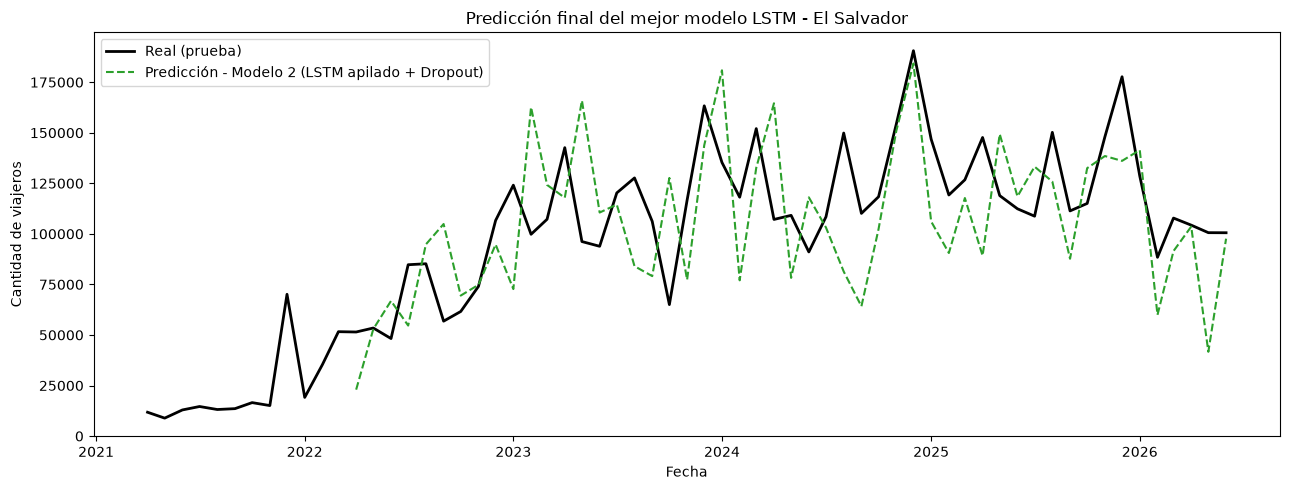

In [18]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_test, color='black', linewidth=2, label='Real (prueba)')
ax.plot(fechas_mejor, pred_mejor, linestyle='--', color='tab:green', label=f'Predicción - {nombre_mejor}')
ax.set_title(f'Predicción final del mejor modelo LSTM - {PAIS}')
ax.set_xlabel('Fecha'); ax.set_ylabel('Cantidad de viajeros')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 8. Comparación contra el mejor modelo del Laboratorio 1 

En el Laboratorio 1 (`serie_paises_residencia.ipynb`), **Prophet** fue el mejor modelo para
El Salvador (menor MAE/RMSE de los cinco modelos comparados: SARIMA, Holt-Winters, SES,
Seasonal Naive y Prophet). Para comparar de forma directa y reproducible dentro de esta misma
libreta, se reajusta Prophet con la misma configuración del Laboratorio 1 sobre `serie_train`
y se pronostica el mismo horizonte de prueba, en vez de solo copiar la métrica ya reportada.

In [21]:
from prophet import Prophet

dfp = serie_train.reset_index()
dfp.columns = ['ds', 'y']

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(dfp)

futuro = m.make_future_dataframe(periods=len(serie_test), freq='MS')
fcst = m.predict(futuro)
pred_prophet = fcst.set_index('ds')['yhat'].iloc[-len(serie_test):].clip(lower=0)
pred_prophet.index = serie_test.index

mae_prophet, rmse_prophet = metricas(serie_test, pred_prophet)
print(f"Prophet (Laboratorio 1) sobre el mismo conjunto de prueba -> MAE={mae_prophet:,.1f}  RMSE={rmse_prophet:,.1f}")

22:38:06 - cmdstanpy - INFO - Chain [1] start processing
22:38:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet (Laboratorio 1) sobre el mismo conjunto de prueba -> MAE=52,289.3  RMSE=58,497.8


In [22]:
tabla_final = pd.DataFrame([
    {'Modelo': f'{nombre_mejor} (Laboratorio 2)', 'MAE': round(mae_mejor, 1), 'RMSE': round(rmse_mejor, 1)},
    {'Modelo': 'Prophet (Laboratorio 1, mejor modelo clásico)', 'MAE': round(mae_prophet, 1), 'RMSE': round(rmse_prophet, 1)},
]).sort_values('RMSE').reset_index(drop=True)
tabla_final

,Modelo,MAE,RMSE
0,Modelo 2 (LSTM apilado + Dropout) (Laboratorio 2),27407.2,33615.6
1,"Prophet (Laboratorio 1, mejor modelo clásico)",52289.3,58497.8


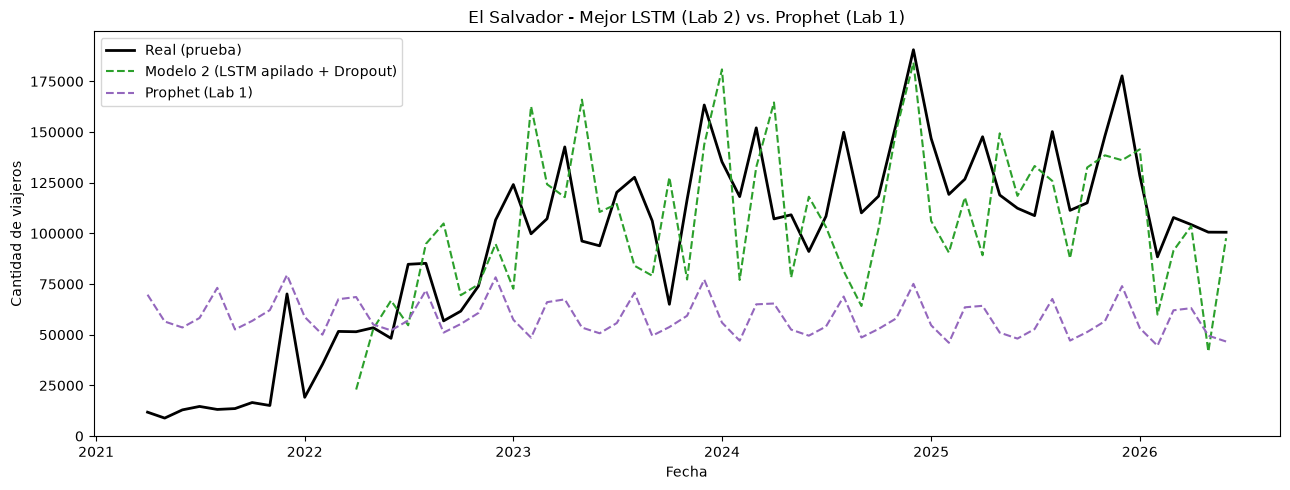

In [23]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_test, color='black', linewidth=2, label='Real (prueba)')
ax.plot(fechas_mejor, pred_mejor, linestyle='--', color='tab:green', label=nombre_mejor)
ax.plot(pred_prophet.index, pred_prophet.values, linestyle='--', color='tab:purple', label='Prophet (Lab 1)')
ax.set_title(f'{PAIS} - Mejor LSTM (Lab 2) vs. Prophet (Lab 1)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Cantidad de viajeros')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Conclusión:**

El mejor modelo para El Salvador es el Modelo 2 (LSTM apilado + Dropout), que 
ya le había ganado al Modelo 1 en la sección 6 (MAE = 27,407.2 vs. 28,664.8; RMSE = 33,615.6 vs. 38,815.3),
 una mejora de ~4.4% en MAE y ~13.4% en RMSE.

**¿Es mejor que el Laboratorio 1?** Sí, y por un margen amplio. Prophet —el mejor modelo clásico para esta serie en 
el Laboratorio 1— obtuvo MAE = 52,289.3 y RMSE = 58,497.8 al reajustarlo aquí sobre el mismo conjunto de prueba. 
El LSTM Modelo 2 reduce el MAE en 47.6% y el RMSE en 42.5% frente a Prophet.

**¿Cómo lo determinamos?** Comparando MAE y RMSE sobre el mismo conjunto de prueba 
(63 meses que ninguno de los dos modelos vio durante su ajuste ni su tuneo), no con AIC/BIC, porque esas métricas 
solo miden ajuste dentro de la muestra de entrenamiento (que termina en plena pandemia) y no la capacidad real de 
generalizar a la recuperación pos-2021 que domina el conjunto de prueba.


**¿Por qué gana el LSTM?** El Salvador es una de las series con dinámica interna más irregular del grupo 
"cercano" (junto con Honduras): rachas más cortas, mayor no linealidad y una recuperación pos-pandemia más 
abrupta que la de países como Estados Unidos. Prophet modela la tendencia principalmente con unos pocos 
changepoints y una estacionalidad anual suave, lo cual le cuesta seguir estos 
rebotes bruscos. El LSTM, en cambio, al trabajar sobre la serie diferenciada con una ventana de 12 meses, 
puede aprender directamente de la forma reciente de esos rebotes en vez de asumir una forma de tendencia 
predefinida, lo que le da ventaja justo en el tipo de serie más volátil como esta.